# inference_noisem2best

Noise-model inference checks for the **m2p3** noise model (`biasnoisem2nest`), with `bx=32`, `n_train=10000`, `_best-rand30` checkpoints.

**Fiducial statistics:** $P_{gg}$; $P_{gg}+P_{gm}$; $P_{gg}+B$ ($k_\text{max}^\text{bispec}=0.25$); $P_{gg}+B+P_{gm}$ (bispec $k_\text{max}^\text{bispec}=0.25$).

**Sections:** SHAMe OOD mock; fixed-cosmo mean with `noisem2best` test bias.


In [1]:
import sys
from pathlib import Path

try:
    REPO_ROOT = Path(__file__).resolve().parents[1]
except NameError:
    _cwd = Path.cwd().resolve()
    if (_cwd / "code").is_dir():
        REPO_ROOT = _cwd
    elif _cwd.name == "notebooks" and (_cwd.parent / "code").is_dir():
        REPO_ROOT = _cwd.parent
    elif _cwd.name == "code":
        REPO_ROOT = _cwd.parent
    else:
        REPO_ROOT = _cwd

sys.path.insert(0, str(REPO_ROOT / "code"))

import numpy as np
import matplotlib.colors as mcolors
from matplotlib import pyplot as plt

import paths
import plotter
import data_loader
import generate_params as genp
import utils_plot

%load_ext autoreload
%autoreload 2


In [2]:
# Shared configuration
bx = 32
n_train = 10000
TAG_INF_BEST_SUFFIX = "_best-rand30"

data_mode = "muchisimocks"
TAG_PARAMS_TRAIN = "_p5_n10000"
TAG_BIASPARAMS_TRAIN = "_biasnoisem2nest_p7_n320000"
TAG_NOISE_TRAIN = "_noise_unit_p5_n10000"
tag_reparam = "_rp"

# Fiducial statistics (same for noisem2, noisenest, fixed-cosmo tests, etc.)
STATISTICS_ARR_FID = [
    ["pk"],
    ["pk", "pgm"],
    ["pk", "bispec"],
    ["pk", "bispec", "pgm"],
]
TAGS_MASK_FID = ["", "", "_kb0.25", "_kb0.25"]

# kpgm scale-cut comparisons (separate triangle plots only)
STATISTICS_ARR_CMP_PGM = [["pk", "pgm"], ["pk", "pgm"]]
TAGS_MASK_CMP_PGM = ["", "_kpgm0.25"]

STATISTICS_ARR_CMP_BSPEC_PGM = [["pk", "bispec", "pgm"], ["pk", "bispec", "pgm"]]
TAGS_MASK_CMP_BSPEC_PGM = ["_kb0.25", "_kb0.25_kpgm0.25"]

# Fixed-cosmo test tags
TAG_PARAMS_TEST_FIXED = "_shame_p0_n1000"
TAG_BIASPARAMS_TEST = "_biasshame_noisem2best_p0_n1"
TAG_NOISE_TEST_FIXED = "_noise_unit_shame_p0_n1000"
TAG_DATAGEN_TEST_MEAN = "_mean"

DATA_MODE_TEST_SHAME = "shame"
TAG_MOCK_SHAME = "_nbar0.00022"
NBAR_LABEL = "0.00022"

ANOISE_OPTION = "Anmultm2p3"
PARAM_NAMES_ZOOM = ["omega_cold", "sigma8_cold", "b1", "An2_homog"]
idx_obs = 0

extents = {
    **genp.get_bounds("cosmo"),
    **genp.get_bounds("bias"),
    **genp.get_bounds("Anoise", anoise_option=ANOISE_OPTION),
}
extents_mid = extents.copy()
extents_narrow = extents.copy()
FIGSIZE_CORNER = (6, 6)
FIGSIZE_ALL_PARAMS = (9, 9)
FONTSIZE_LEGEND = 12
KMAX_DEFAULT = 0.4
FIDUCIAL_KMAX_BISPEC = 0.25
FIDUCIAL_KMAX_PGM = KMAX_DEFAULT
LOC_LEGEND = (1.02, 0.98)
dir_sbi = paths.DIR_RESULTS / "results_sbi"

def tag_stats_arr(statistics_arr, tags_mask):
    """Stat suffix with mask appended (train tags, SHAMe OOD)."""
    return [f'_{"_".join(s)}' + m for s, m in zip(statistics_arr, tags_mask)]

def tag_stats_test_arr(statistics_arr):
    """Base stat suffix only; masks go to setup_test_tags separately."""
    return [f'_{"_".join(s)}' for s in statistics_arr]

def sample_fn(tag_inf, tag_test):
    return dir_sbi / f"sbi{tag_inf}" / f"samples_test{tag_test}_pred.npy"

def samples_exist(tags_inf, tags_test):
    return [sample_fn(ti, tt).exists() for ti, tt in zip(tags_inf, tags_test)]

def print_available(title, labels, tags_inf, tags_test, keep):
    print(title)
    for lbl, k, ti, tt in zip(labels, keep, tags_inf, tags_test):
        print(f"  [{'x' if k else ' '}] {lbl}")
        if not k:
            print(f"       missing: {sample_fn(ti, tt)}")

def _print_missing(tags_inf, tags_test, labels, keep, idxs=None):
    for i in (idxs if idxs is not None else range(len(keep))):
        if i < len(keep) and not keep[i]:
            print(f"  missing [{labels[i]}]: {sample_fn(tags_inf[i], tags_test[i])}")

def setup_inference(tag_biasparams_train, statistics_arr, tags_mask):
    tags_inf, labels, colors, _ = utils_plot.setup_inference_tags(
        data_mode=data_mode,
        tag_params=TAG_PARAMS_TRAIN,
        tag_biasparams=tag_biasparams_train,
        statistics_arr=statistics_arr,
        bx=bx,
        tag_noise=TAG_NOISE_TRAIN,
        tag_reparam=tag_reparam,
        n_train=n_train,
        tags_mask=tags_mask,
    )
    tags_inf = [t + TAG_INF_BEST_SUFFIX for t in tags_inf]
    return tags_inf, labels, colors

def pp_style_colors(n_chains):
    """Reversed plasma, matching kmax PP / coverage plots."""
    return [
        mcolors.to_hex(c)
        for c in plt.cm.plasma_r(np.linspace(0.25, 0.95, max(n_chains, 1)))
    ]


def _kmax_numeric(tags_mask, *, focus="pgm"):
    for mask_part in tags_mask.split("_"):
        if not mask_part:
            continue
        if focus == "pgm" and mask_part.startswith("kpgm"):
            return float(mask_part[len("kpgm"):])
        if focus == "bispec" and mask_part.startswith("kb"):
            return float(mask_part[len("kb"):])
    if focus == "pgm":
        return KMAX_DEFAULT
    if focus == "bispec":
        return KMAX_DEFAULT
    return KMAX_DEFAULT


def pp_style_colors_for_kmax(idxs, tags_mask, focus="pgm"):
    """Colors by k_max (tight→light, loose→dark), matching kmax sweep notebooks."""
    kvals = [_kmax_numeric(tags_mask[i], focus=focus) for i in idxs]
    kmin, kmax = min(kvals), max(kvals)
    return [
        mcolors.to_hex(plt.cm.plasma_r(0.25 + 0.7 * ((kv - kmin) / (kmax - kmin) if kmax > kmin else 0.5)))
        for kv in kvals
    ]


def _kmax_cmp_legend_label(tags_mask, *, focus="pgm"):
    for mask_part in tags_mask.split("_"):
        if not mask_part:
            continue
        if focus == "pgm" and mask_part.startswith("kpgm"):
            return rf"$k_\text{{max}}^\text{{pgm}}={float(mask_part[len('kpgm'):])}$"
        if focus == "bispec" and mask_part.startswith("kb"):
            return rf"$k_\text{{max}}^\text{{bispec}}={float(mask_part[len('kb'):])}$"
    if focus == "pgm":
        return rf"$k_\text{{max}}^\text{{pgm}}={KMAX_DEFAULT}$"
    if focus == "bispec":
        return rf"$k_\text{{max}}^\text{{bispec}}={KMAX_DEFAULT}$"
    ml = utils_plot.get_mask_label(tags_mask)
    return ml if ml else rf"$k_\text{{max}}={KMAX_DEFAULT}$"


def _kmax_cmp_legend_labels(tags_mask, idxs, focus="pgm"):
    return [_kmax_cmp_legend_label(tags_mask[i], focus=focus) for i in idxs]


def _fiducial_title_with_kmax(title):
    sub = (
        rf"$k_\text{{max}}^\text{{bispec}}={FIDUCIAL_KMAX_BISPEC}$, "
        rf"$k_\text{{max}}^\text{{pgm}}={FIDUCIAL_KMAX_PGM}$"
    )
    return f"{title}\n{sub}"

def setup_shame_ood(tag_biasparams_train, statistics_arr, tags_mask):
    tags_inf, labels, colors = setup_inference(tag_biasparams_train, statistics_arr, tags_mask)
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, tag_biasparams_train, bx=bx,
    )
    tags_test = utils_plot.setup_shame_mock_test_tags(
        tag_stats_arr=tag_stats_arr(statistics_arr, tags_mask),
        data_mode_test=DATA_MODE_TEST_SHAME,
        tag_mock=TAG_MOCK_SHAME,
    )
    keep = samples_exist(tags_inf, tags_test)
    return tags_inf, labels, colors, tags_test, keep, cosmo_vary, bias_vary, param_vary

def setup_fixed_mean(tag_biasparams_train, tag_biasparams_test, statistics_arr, tags_mask):
    tags_inf, labels, colors = setup_inference(tag_biasparams_train, statistics_arr, tags_mask)
    cosmo_vary, bias_vary, param_vary = utils_plot.load_training_params(
        TAG_PARAMS_TRAIN, tag_biasparams_train, bx=bx,
    )
    tags_test = utils_plot.setup_test_tags(
        data_mode=data_mode,
        tag_params_test=TAG_PARAMS_TEST_FIXED,
        tags_biasparams_test=tag_biasparams_test,
        tag_stats_arr=tag_stats_test_arr(statistics_arr),
        tag_noise_test=TAG_NOISE_TEST_FIXED,
        tag_datagen_test=TAG_DATAGEN_TEST_MEAN,
        tags_mask_test=tags_mask,
    )
    keep = samples_exist(tags_inf, tags_test)
    theta = data_loader.load_theta_test(
        TAG_PARAMS_TEST_FIXED,
        tag_biasparams_test,
        cosmo_param_names_vary=cosmo_vary,
        bias_param_names_vary=bias_vary,
    )
    theta_obs = theta[idx_obs] if theta.ndim == 2 else theta
    idxs_zoom = [param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]
    return tags_inf, labels, colors, tags_test, keep, theta_obs, theta_obs[idxs_zoom], param_vary

def _select_available(idxs, keep):
    return [i for i in idxs if keep[i]]


def _contour_param_names(param_names):
    """Always include An2_homog in contour plots."""
    names = list(param_names)
    if "An2_homog" not in names:
        names.append("An2_homog")
    return names


def _extents_all_params():
    return {
        **genp.get_bounds("cosmo"),
        **genp.get_bounds("bias"),
        **genp.get_bounds("Anoise", anoise_option=ANOISE_OPTION),
    }


def plot_fiducial_triangle(
    tags_inf, labels, colors, tags_test, keep, title, theta_show, *,
    tags_mask, extents=None,
):
    """All fiducial statistics on one triangle plot (color_dict_statistics)."""
    idxs = _select_available(range(len(keep)), keep)
    if not idxs:
        print(f"No fiducial samples on disk for: {title}")
        _print_missing(tags_inf, tags_test, labels, keep)
        return
    if extents is None:
        extents = extents_mid
    plot_title = _fiducial_title_with_kmax(title)
    plotter.plot_contours_inf(
        param_names=_contour_param_names(PARAM_NAMES_ZOOM),
        idx_obs=idx_obs,
        theta_obs_true=theta_show,
        inf_methods=["sbi"] * len(idxs),
        tags_inf=[tags_inf[i] for i in idxs],
        tags_test=[tags_test[i] for i in idxs],
        colors=[colors[i] for i in idxs],
        labels=[labels[i] for i in idxs],
        title=plot_title,
        extents=extents,
        figsize=FIGSIZE_CORNER,
        fontsize_legend=FONTSIZE_LEGEND,
        loc_legend=LOC_LEGEND,
        unreparameterize=True,
    )

def plot_kpgm_cmp_triangle(
    tags_inf, labels, colors, tags_test, keep, title, theta_show, *,
    tags_mask, cmp_idxs=(0, 1), kmax_focus="pgm",
):
    """Compare two scale cuts (plasma colors, legend = k_max only)."""
    idxs = [i for i in cmp_idxs if i < len(keep) and keep[i]]
    if len(idxs) < 1:
        print(f"No samples on disk for: {title}")
        _print_missing(tags_inf, tags_test, labels, keep, cmp_idxs)
        return
    plotter.plot_contours_inf(
        param_names=_contour_param_names(PARAM_NAMES_ZOOM),
        idx_obs=idx_obs,
        theta_obs_true=theta_show,
        inf_methods=["sbi"] * len(idxs),
        tags_inf=[tags_inf[i] for i in idxs],
        tags_test=[tags_test[i] for i in idxs],
        colors=pp_style_colors_for_kmax(idxs, tags_mask, focus=kmax_focus),
        labels=_kmax_cmp_legend_labels(tags_mask, idxs, focus=kmax_focus),
        title=title,
        extents=extents_narrow,
        figsize=FIGSIZE_CORNER,
        fontsize_legend=FONTSIZE_LEGEND,
        loc_legend=LOC_LEGEND,
        unreparameterize=True,
    )


def plot_all_params_fiducial(
    tags_inf, labels, colors, tags_test, keep, title, theta_obs, param_vary, *,
    extents=None,
):
    """All varied parameters, all fiducial statistics on one corner plot."""
    idxs = _select_available(range(len(keep)), keep)
    if not idxs:
        print(f"No samples on disk for all-params plot: {title}")
        _print_missing(tags_inf, tags_test, labels, keep)
        return
    if extents is None:
        extents = _extents_all_params()
    plotter.plot_contours_inf(
        param_names=_contour_param_names(param_vary),
        idx_obs=idx_obs,
        theta_obs_true=theta_obs,
        inf_methods=["sbi"] * len(idxs),
        tags_inf=[tags_inf[i] for i in idxs],
        tags_test=[tags_test[i] for i in idxs],
        colors=[colors[i] for i in idxs],
        labels=[labels[i] for i in idxs],
        title=title,
        extents=extents,
        figsize=FIGSIZE_ALL_PARAMS,
        fontsize_legend=FONTSIZE_LEGEND,
        loc_legend=LOC_LEGEND,
        unreparameterize=True,
    )


## SHAMe OOD — noisem2

In [3]:
(
    tags_inf_m2, labels_m2, colors_m2, tags_test_m2, keep_m2,
    cosmo_vary, bias_vary, param_vary,
) = setup_shame_ood(TAG_BIASPARAMS_TRAIN, STATISTICS_ARR_FID, TAGS_MASK_FID)
inf_m2 = ["sbi"] * len(tags_inf_m2)
print_available("SHAMe OOD, noisem2 — fiducial:", labels_m2, tags_inf_m2, tags_test_m2, keep_m2)

theta_ood = data_loader.load_theta_ood(
    DATA_MODE_TEST_SHAME, TAG_MOCK_SHAME,
    cosmo_param_names_vary=cosmo_vary, bias_param_names_vary=bias_vary,
)
theta_obs = theta_ood[idx_obs] if theta_ood.ndim == 2 else theta_ood
theta_zoom = theta_obs[[param_vary.index(pn) for pn in PARAM_NAMES_ZOOM]]


SHAMe OOD, noisem2 — fiducial:
  [x] $P_\mathrm{gg}(k)$
  [x] $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy


Parameter An2_homog in chain $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$ is not constrained


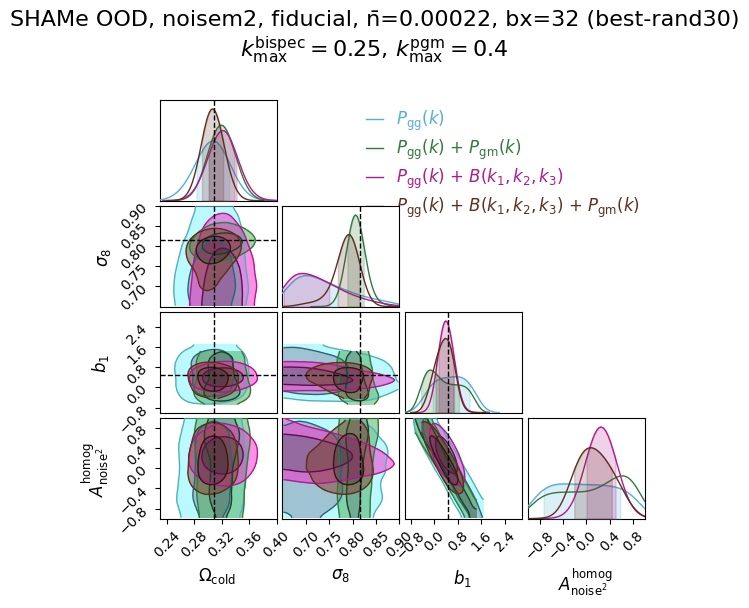

In [4]:
plot_fiducial_triangle(
    tags_inf_m2, labels_m2, colors_m2, tags_test_m2, keep_m2,
    f"SHAMe OOD, noisem2, fiducial, n̄={NBAR_LABEL}, bx={bx} (best-rand30)",
    theta_zoom,
    tags_mask=TAGS_MASK_FID,
)


### All varied parameters (fiducial)


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy


Parameter An_homog in chain $P_\mathrm{gg}(k)$ is not constrained
Parameter An_homog in chain $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$ is not constrained
Parameter An_homog in chain $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ is not constrained
Parameter An_homog in chain $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$ is not constrained
Parameter An2_homog in chain $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$ is not constrained


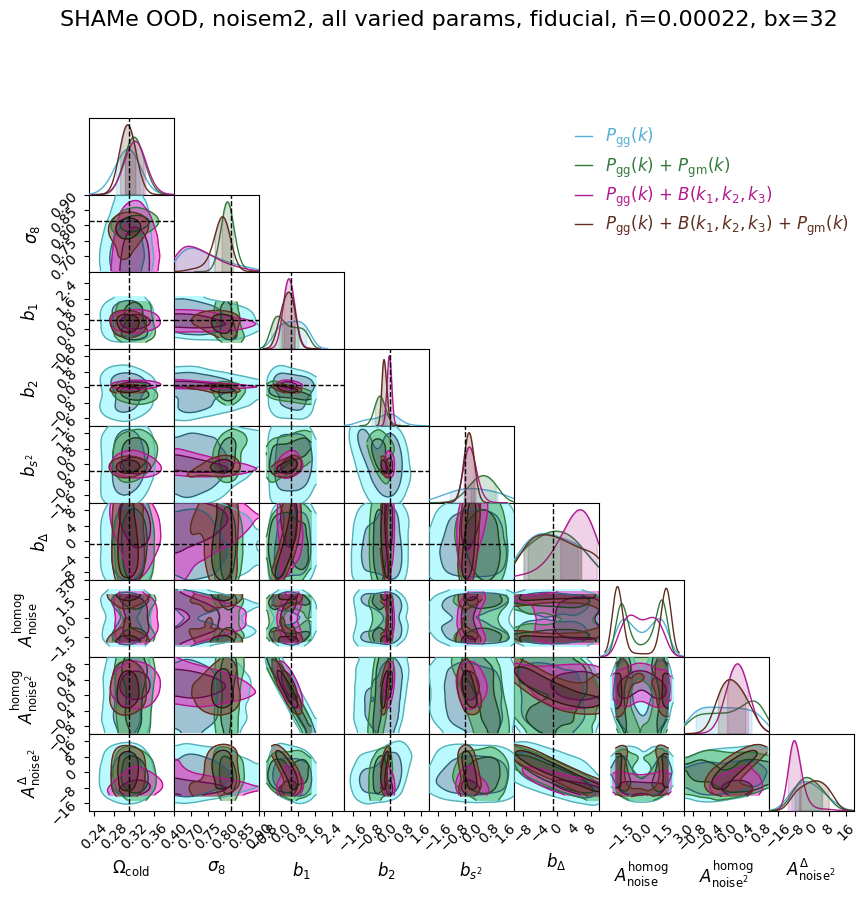

In [5]:
plot_all_params_fiducial(
    tags_inf_m2, labels_m2, colors_m2, tags_test_m2, keep_m2,
    f"SHAMe OOD, noisem2, all varied params, fiducial, n̄={NBAR_LABEL}, bx={bx}",
    theta_obs, param_vary,
)


### $P_{gm}$ scale cut — $P_{gg}+P_{gm}$

Parameter An2_homog in chain $k_\text{max}^\text{pgm}=0.4$ is not constrained


SHAMe OOD, noisem2 — pk+pgm kpgm compare:
  [x] $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_pgm_kpgm0.25_nbar0.00022_pred.npy


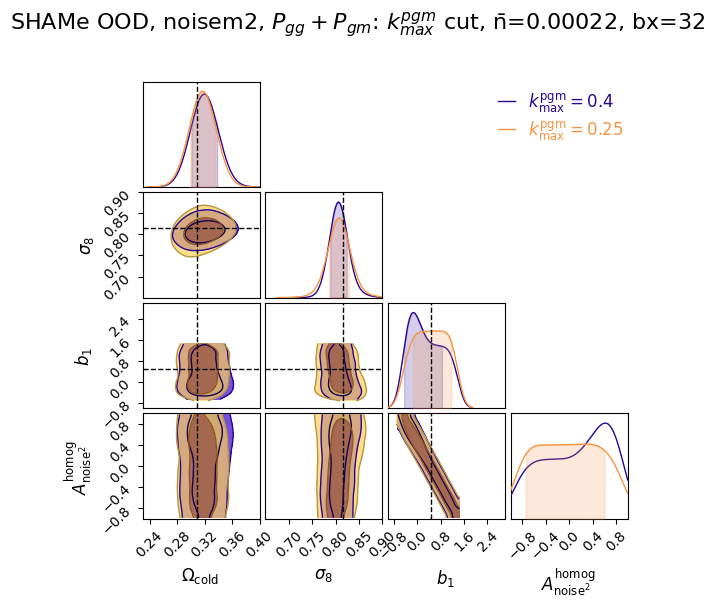

In [6]:
(
    tags_inf_m2_pgm, labels_m2_pgm, colors_m2_pgm, tags_test_m2_pgm, keep_m2_pgm,
    *_,
) = setup_shame_ood(TAG_BIASPARAMS_TRAIN, STATISTICS_ARR_CMP_PGM, TAGS_MASK_CMP_PGM)
print_available("SHAMe OOD, noisem2 — pk+pgm kpgm compare:", labels_m2_pgm, tags_inf_m2_pgm, tags_test_m2_pgm, keep_m2_pgm)

plot_kpgm_cmp_triangle(
    tags_inf_m2_pgm, labels_m2_pgm, colors_m2_pgm, tags_test_m2_pgm, keep_m2_pgm,
    f"SHAMe OOD, noisem2, $P_{{gg}}+P_{{gm}}$: $k_{{max}}^{{pgm}}$ cut, n̄={NBAR_LABEL}, bx={bx}",
    theta_zoom,
    tags_mask=TAGS_MASK_CMP_PGM,
)


### $P_{gm}$ scale cut — $P_{gg}+B+P_{gm}$ (bispec $k_\text{max}^\text{bispec}=0.25$)

SHAMe OOD, noisem2 — pk+bispec+pgm kpgm compare:
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_nbar0.00022_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_shame_pk_bispec_pgm_kb0.25_kpgm0.25_nbar0.00022_pred.npy


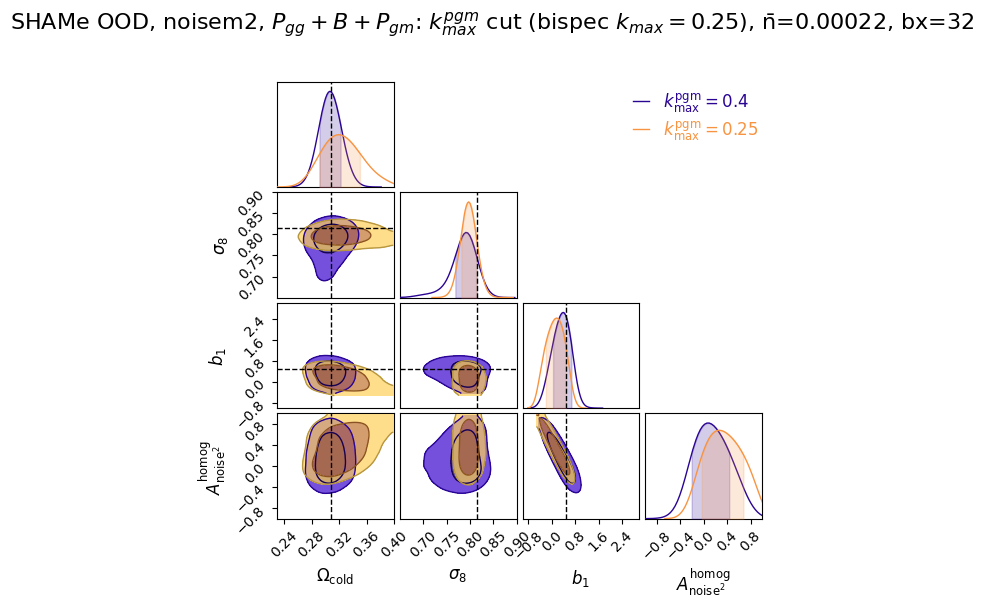

In [15]:
(
    tags_inf_m2_bp, labels_m2_bp, colors_m2_bp, tags_test_m2_bp, keep_m2_bp,
    *_,
) = setup_shame_ood(TAG_BIASPARAMS_TRAIN, STATISTICS_ARR_CMP_BSPEC_PGM, TAGS_MASK_CMP_BSPEC_PGM)
print_available("SHAMe OOD, noisem2 — pk+bispec+pgm kpgm compare:", labels_m2_bp, tags_inf_m2_bp, tags_test_m2_bp, keep_m2_bp)

plot_kpgm_cmp_triangle(
    tags_inf_m2_bp, labels_m2_bp, colors_m2_bp, tags_test_m2_bp, keep_m2_bp,
    f"SHAMe OOD, noisem2, $P_{{gg}}+B+P_{{gm}}$: $k_{{max}}^{{pgm}}$ cut (bispec $k_{{max}}=0.25$), n̄={NBAR_LABEL}, bx={bx}",
    theta_zoom,
    tags_mask=TAGS_MASK_CMP_BSPEC_PGM,
)


## Fixed cosmo mean — noisem2best

In [9]:
(
    tags_inf_m2b, labels_m2b, colors_m2b, tags_test_m2b, keep_m2b,
    theta_obs_m2b, theta_zoom_m2b, param_vary_m2b,
) = setup_fixed_mean(
    TAG_BIASPARAMS_TRAIN,
    TAG_BIASPARAMS_TEST,
    STATISTICS_ARR_FID,
    TAGS_MASK_FID,
)
inf_m2b = ["sbi"] * len(tags_inf_m2b)
print_available("Fixed cosmo mean, noisem2best — fiducial:", labels_m2b, tags_inf_m2b, tags_test_m2b, keep_m2b)


Fixed cosmo mean, noisem2best — fiducial:
  [x] $P_\mathrm{gg}(k)$
  [x] $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_noisem2best_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_shame_p0_n1000_biasshame_noisem2best_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.25_shame_p0_n1000_biasshame_noisem2best_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n

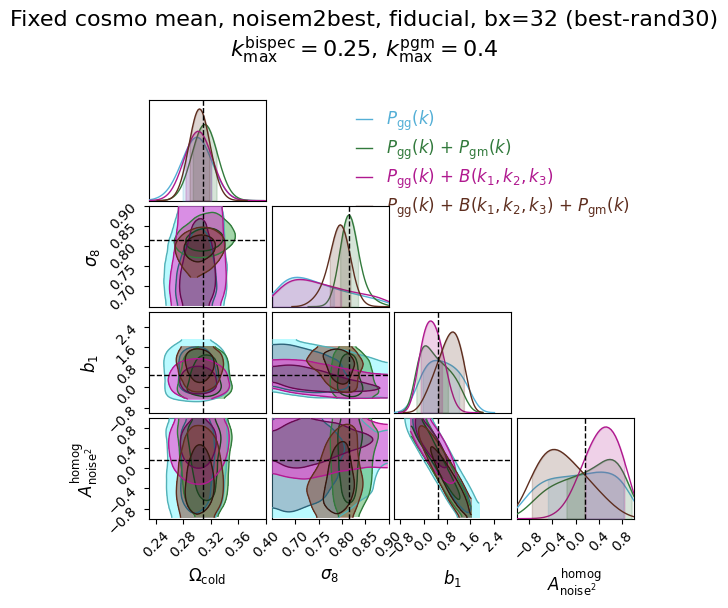

In [10]:
plot_fiducial_triangle(
    tags_inf_m2b, labels_m2b, colors_m2b, tags_test_m2b, keep_m2b,
    f"Fixed cosmo mean, noisem2best, fiducial, bx={bx} (best-rand30)",
    theta_zoom_m2b,
    tags_mask=TAGS_MASK_FID,
)


### All varied parameters (fiducial)


fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_shame_p0_n1000_biasshame_noisem2best_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_shame_p0_n1000_biasshame_noisem2best_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_kb0.25_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_kb0.25_shame_p0_n1000_biasshame_noisem2best_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n

Parameter An_homog in chain $P_\mathrm{gg}(k)$ is not constrained
Parameter An_homog in chain $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$ is not constrained
Parameter An_homog in chain $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ is not constrained
Parameter An_homog in chain $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$ is not constrained


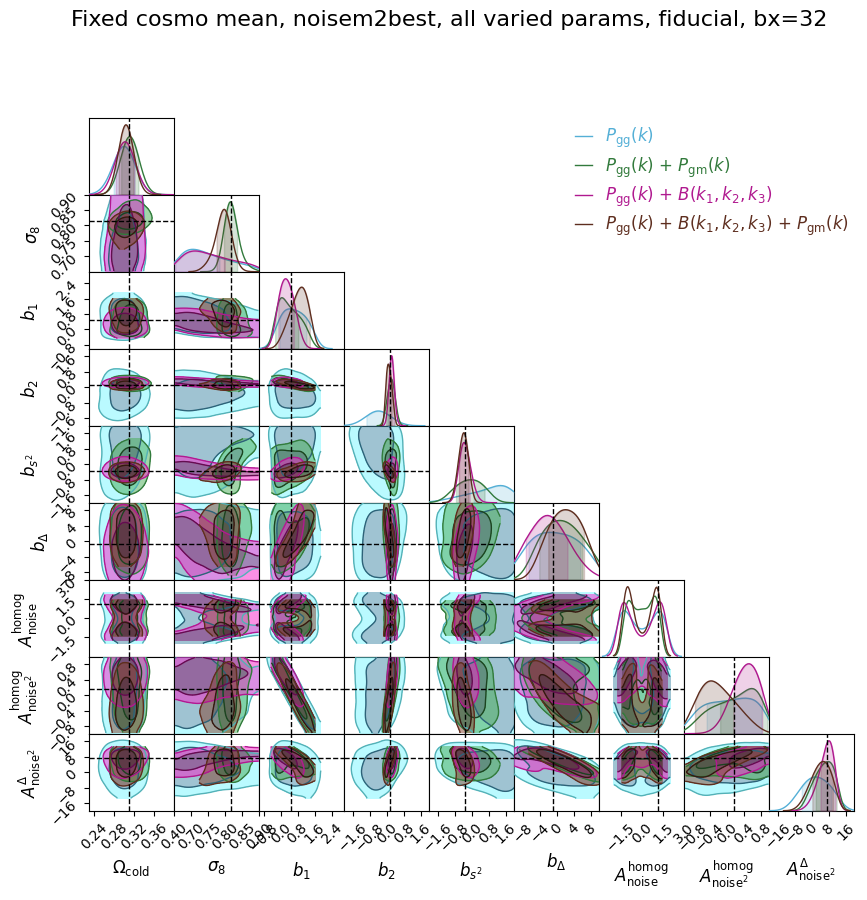

In [11]:
plot_all_params_fiducial(
    tags_inf_m2b, labels_m2b, colors_m2b, tags_test_m2b, keep_m2b,
    f"Fixed cosmo mean, noisem2best, all varied params, fiducial, bx={bx}",
    theta_obs_m2b, param_vary_m2b,
)


### $P_{gm}$ scale cut — $P_{gg}+P_{gm}$

Fixed cosmo mean, noisem2best — pk+pgm kpgm compare:
  [x] $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $P_\mathrm{gm}(k)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_shame_p0_n1000_biasshame_noisem2best_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_pgm_kpgm0.25_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_pgm_kpgm0.25_shame_p0_n1000_biasshame_noisem2best_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy


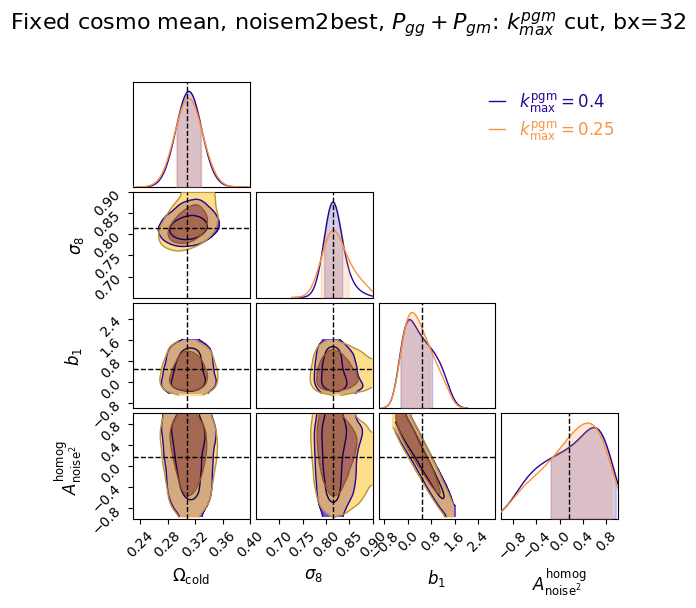

In [12]:
(
    tags_inf_m2b_pgm, labels_m2b_pgm, colors_m2b_pgm, tags_test_m2b_pgm, keep_m2b_pgm,
    _, theta_zoom_m2b, _,
) = setup_fixed_mean(
    TAG_BIASPARAMS_TRAIN,
    TAG_BIASPARAMS_TEST,
    STATISTICS_ARR_CMP_PGM,
    TAGS_MASK_CMP_PGM,
)
print_available("Fixed cosmo mean, noisem2best — pk+pgm kpgm compare:", labels_m2b_pgm, tags_inf_m2b_pgm, tags_test_m2b_pgm, keep_m2b_pgm)

plot_kpgm_cmp_triangle(
    tags_inf_m2b_pgm, labels_m2b_pgm, colors_m2b_pgm, tags_test_m2b_pgm, keep_m2b_pgm,
    f"Fixed cosmo mean, noisem2best, $P_{{gg}}+P_{{gm}}$: $k_{{max}}^{{pgm}}$ cut, bx={bx}",
    theta_zoom_m2b,
    tags_mask=TAGS_MASK_CMP_PGM,
)


### $P_{gm}$ scale cut — $P_{gg}+B+P_{gm}$ (bispec $k_\text{max}^\text{bispec}=0.25$)

Fixed cosmo mean, noisem2best — pk+bispec+pgm kpgm compare:
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
  [x] $P_\mathrm{gg}(k)$ + $B(k_1,k_2,k_3)$ + $P_\mathrm{gm}(k)$
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_shame_p0_n1000_biasshame_noisem2best_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy
fn_samples = /scratch/kstoreyf/muchisimocks/results/results_sbi/sbi_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_p5_n10000_biasnoisem2nest_p7_n320000_noise_unit_p5_n10000_rp_bx32_ntrain10000_best-rand30/samples_test_muchisimocks_pk_bispec_pgm_kb0.25_kpgm0.25_shame_p0_n1000_biasshame_noisem2best_p0_n1_noise_unit_shame_p0_n1000_mean_pred.npy


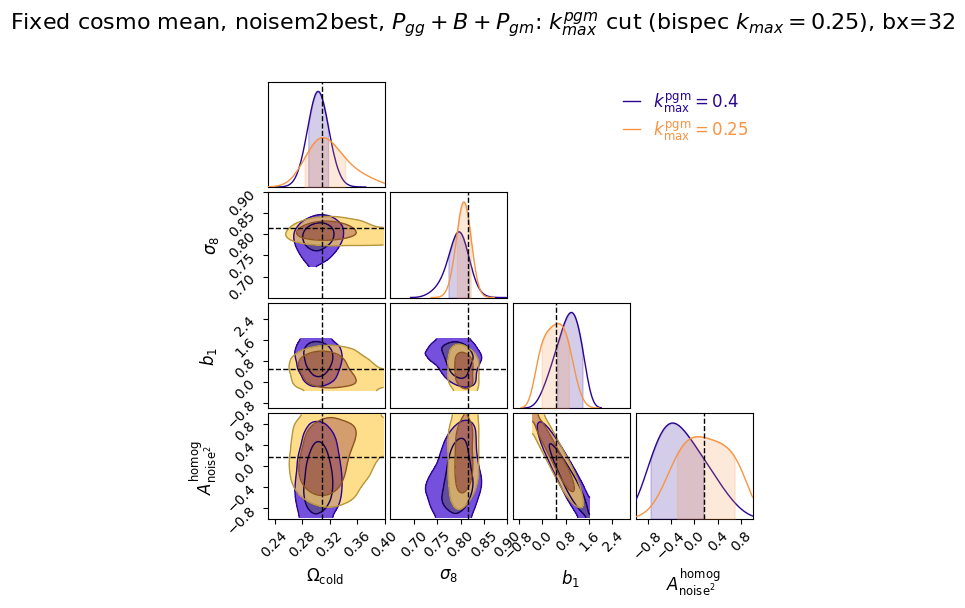

In [16]:
(
    tags_inf_m2b_bp, labels_m2b_bp, colors_m2b_bp, tags_test_m2b_bp, keep_m2b_bp,
    _, theta_zoom_m2b, _,
) = setup_fixed_mean(
    TAG_BIASPARAMS_TRAIN,
    TAG_BIASPARAMS_TEST,
    STATISTICS_ARR_CMP_BSPEC_PGM,
    TAGS_MASK_CMP_BSPEC_PGM,
)
print_available("Fixed cosmo mean, noisem2best — pk+bispec+pgm kpgm compare:", labels_m2b_bp, tags_inf_m2b_bp, tags_test_m2b_bp, keep_m2b_bp)

plot_kpgm_cmp_triangle(
    tags_inf_m2b_bp, labels_m2b_bp, colors_m2b_bp, tags_test_m2b_bp, keep_m2b_bp,
    f"Fixed cosmo mean, noisem2best, $P_{{gg}}+B+P_{{gm}}$: $k_{{max}}^{{pgm}}$ cut (bispec $k_{{max}}=0.25$), bx={bx}",
    theta_zoom_m2b,
    tags_mask=TAGS_MASK_CMP_BSPEC_PGM,
)
